In [2]:
# import general packages
import numpy as np
import pandas as pd

# Matplotlib
from matplotlib import pyplot as plt
from matplotlib import cm
import matplotlib.gridspec as gspec #import GridSpec
from matplotlib import transforms
import json

%matplotlib notebook


### Load data

In [3]:
with open("data_fig4_SEDOR_spectroscopy.json") as file:
    data_dict_spectroscopy = json.load(file)

with open("data_fig4_SEDOR_tau_sweep.json") as file:
    data_dict_tau_sweep = json.load(file)
    
with open("data_fig4_1D_ENES.json") as file:
    data_dict_1D = json.load(file)

with open("data_fig4_2D_ENES.json") as file:
    data_dict = json.load(file)
data_dict['PSD2D'] = np.array(data_dict['PSD2D']).reshape(len(data_dict['f1']),len(data_dict['f2']))
data_dict['data_2D'] = np.array(data_dict['data_2D']).reshape(len(data_dict['x1']),len(data_dict['x2']))
    
    
with open("data_fig4_sim_1D.json") as file:
    sim_dict_1D = json.load(file)
    
with open("data_fig4_sim_2D.json") as file:
    sim_dict_2D = json.load(file)

### Plotting Params

In [4]:
# General
plt.style.use('seaborn-deep')

axes_color =  '0.8'

plt.rcParams.update({'font.size': 7,
                     'font.family':r'Arial',
                     'font.style':'normal',
                     'axes.grid' : False,
                     'axes.edgecolor': axes_color,
                     'ytick.color': '.15',
                     'xtick.color':'.15',
                     'lines.linewidth':1,
                     'axes.labelsize':'medium'

                    })

plt.rcParams['ytick.major.size'] = 3.5
plt.rcParams['ytick.major.width'] = 0.8

plt.rcParams['xtick.major.size'] = 3.5
plt.rcParams['xtick.major.width'] = 0.8

labelpad = 10

PSD_sum_color = 'lightgrey'

data_color_list = ['#588bc5', '#838bc5']

fit_alpha = 0.8

cmap_2D ='viridis' #'YlGnBu'# #'Greys'   #'OrRd'# 'YlGn' #'
cmap_2D = 'Greys'
grey_color = cm.Greys(0.5)

rvmax = 0.5

# Input parameters
f1_min = 7850-300
f1_max = 7850+300
f_larmor = 432.009 #kHz

# Correct for undersampling 1D ENES
dt = np.diff(data_dict_1D['x_vals'])[0]
N_periods = 4 #4
f_0 = dt**(-1)*N_periods*1e3

/var/folders/bj/yvztxw3x02q7p94lvc80kqt4f5p5j8/T/ipykernel_62556/144042356.py:2: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-deep')


### Plot figure

<IPython.core.display.Javascript object>


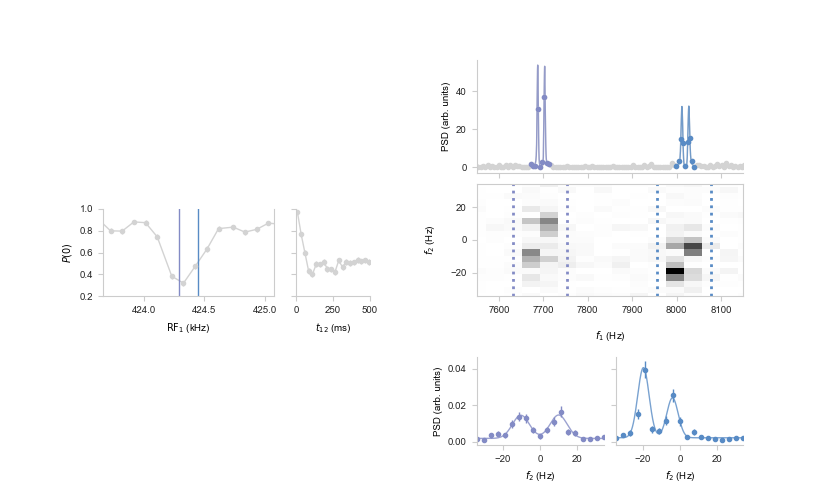

In [5]:
# Define the axes
fig = plt.figure(figsize = [21/2.54,5],constrained_layout=True)
outer = gspec.GridSpec(3,2, width_ratios = [2, 2],hspace = 0.7, wspace = 0.4) 

# right_column
gs0 = gspec.GridSpecFromSubplotSpec(2, 2, subplot_spec = outer[:2,1], hspace = 0.1, wspace = 0.0)
ax_1D_PSD = fig.add_subplot(gs0[0,:])
ax_2D_PSD = fig.add_subplot(gs0[1:,:], sharex = ax_1D_PSD)


gs0b = gspec.GridSpecFromSubplotSpec(1,2, subplot_spec = outer[-1,1],hspace =0.8, wspace = 0.1)
ax_C4 = fig.add_subplot(gs0b[0,1])
ax_C8 = fig.add_subplot(gs0b[0,0], sharey = ax_C4,sharex = ax_C4)

# left column
gs1 = gspec.GridSpecFromSubplotSpec(1, 3, subplot_spec = outer[1,0], wspace = 0.3)
ax_spec = fig.add_subplot(gs1[:,:-1])
ax_tau_sweep = fig.add_subplot(gs1[:,-1])



### SEDOR spectrum ####
ax_spec.plot(data_dict_spectroscopy['x_vals'],
                 data_dict_spectroscopy['y_vals'], 
                 color = PSD_sum_color,
                 
                )
ax_spec.errorbar(data_dict_spectroscopy['x_vals'],
                 data_dict_spectroscopy['y_vals'], 
                 data_dict_spectroscopy['y_err_vals'],
                 color = PSD_sum_color,
                 fmt = '.'
                )

# Spin frequencies
spin_freqs = np.array([424.449, 424.289])
for j, spin_freq in enumerate(spin_freqs):
    ax_spec.axvline(spin_freq, color = data_color_list[j] , linestyle = '-')

center = np.mean(spin_freqs)
ax_spec.set_xlim([center - 0.7,center+0.7])
ax_spec.set_xlabel(r'$\mathrm{RF}_1$ (kHz)')
ax_spec.set_ylabel(r'$P(0)$')
ax_spec.spines["top"].set_visible(False)
ax_spec.set_ylim([0.2, 1.])




### SEDOR tau sweep (correct for tau to t2)
ax_tau_sweep.plot(2*np.array(data_dict_tau_sweep['x_vals']),
                      data_dict_tau_sweep['y_vals'],
                      color = PSD_sum_color,
                     )
ax_tau_sweep.errorbar(2*np.array(data_dict_tau_sweep['x_vals']),
                      data_dict_tau_sweep['y_vals'],
                      data_dict_tau_sweep['y_err_vals'],
                      color = PSD_sum_color,
                      fmt = '.')

ax_tau_sweep.set_xlim([0,500])
ax_tau_sweep.set_yticklabels([])
ax_tau_sweep.set_ylim([0.2, 1.])
ax_tau_sweep.spines['top'].set_visible(False)
ax_tau_sweep.spines['right'].set_visible(False)
xlabel = r'$t_{12}$ (ms)'#.format(str(12))
ax_tau_sweep.set_xlabel(xlabel)
ax_tau_sweep.tick_params(color = axes_color )




#### 1D PSD ###
# Correct for undersampling
dt = np.diff(data_dict_1D['x_vals'])[0]
N_periods = 4 
f_0 = dt**(-1)*N_periods*1e3

ax_1D_PSD.plot(f_0 - data_dict_1D['freq1_fit'], data_dict_1D['PSD1_fit'], color = PSD_sum_color, alpha =fit_alpha)
ax_1D_PSD.errorbar(f_0 - data_dict_1D['freq1'],data_dict_1D['PSD1'],data_dict_1D['PSD1_error'], fmt = '.', color = PSD_sum_color)
ax_1D_PSD.set_xlim([f1_min,f1_max])

# highlight frequencies
index_start = int(275*5.11) 
index_stop  = int(365*5.11)
ax_1D_PSD.plot(f_0-data_dict_1D['freq1_fit'][index_start:index_stop], data_dict_1D['PSD1_fit'][index_start:index_stop], 
               alpha=fit_alpha, 
               color = data_color_list[0]
              )
index_start = int(28)
index_stop  = index_start+9
ax_1D_PSD.errorbar(f_0 - data_dict_1D['freq1'][index_start:index_stop], data_dict_1D['PSD1'][index_start:index_stop],data_dict_1D['PSD1_error'][index_start:index_stop] ,
                   color = data_color_list[0],
                  fmt ='.')

index_start = int(915*5.11)
index_stop  = int(1000*5.11)
ax_1D_PSD.plot(f_0 - data_dict_1D['freq1_fit'][index_start:index_stop], data_dict_1D['PSD1_fit'][index_start:index_stop], 
               alpha=fit_alpha, 
               color = data_color_list[1]
              )
index_start = int(92)  
index_stop  = index_start+9 
ax_1D_PSD.errorbar(f_0 - data_dict_1D['freq1'][index_start:index_stop], data_dict_1D['PSD1'][index_start:index_stop],data_dict_1D['PSD1_error'][index_start:index_stop] ,
                   color = data_color_list[1],
                  fmt ='.')

ax_1D_PSD.set_ylabel('PSD (arb. units)')
ax_1D_PSD.spines["top"].set_visible(False)
ax_1D_PSD.spines["right"].set_visible(False)
ax_1D_PSD.tick_params(labelbottom = False)


### 2D plot ###
# Correct for undersampling
dt = np.diff(data_dict['x1'])[0]
N_periods = 6
f_0 = dt**(-1)*N_periods*1e3

# Frequency domain plot
df1 = np.diff(data_dict['f1'])[0]
df2 = np.diff(data_dict['f2'])[0]
ax_2D_PSD.pcolormesh(f_0 + data_dict['f1'] ,data_dict['f2'] ,np.transpose(data_dict['PSD2D']),  
                 cmap = cmap_2D, 
                 shading = 'auto', 
                 vmax = np.max(data_dict['PSD2D'])*rvmax) #, shading = 'nearest')



# draw vertical lines
index_start_list = [int(len(data_dict['f1'])/2 + 10), int(len(data_dict['f1'])/2 + 2)]
index_stop_list = [int(len(data_dict['f1'])/2 + 14), int(len(data_dict['f1'])/2 + 6)]

for i in [0,1]:
    ax_2D_PSD.axvline(f_0 + data_dict['f1'][index_start_list[i]], color = data_color_list[i], linestyle = 'dotted', linewidth = 2)
    ax_2D_PSD.axvline(f_0 + data_dict['f1'][index_stop_list[i]-1], color = data_color_list[i], linestyle = 'dotted', linewidth = 2)


# ax settings
ax_2D_PSD.set_xlabel('$f_1$ (Hz)', labelpad =labelpad)
ax_2D_PSD.set_ylabel('$f_2$ (Hz)', labelpad =labelpad)
ax_2D_PSD.set_ylim([-np.max(data_dict['f2']) ,np.max(data_dict['f2'])])

### f2-axis signals ###
ax = [ax_C4,ax_C8]
PSD_list = [data_dict['PSD_list_0'],data_dict['PSD_list_1']]
PSD_error_list = [data_dict['PSD_error_list_0'],data_dict['PSD_error_list_1']]

x_fit_list = [data_dict['x_fit_list_0'],data_dict['x_fit_list_1']]
y_fit_list = [data_dict['y_fit_list_0'],data_dict['y_fit_list_1']]

for j in [0,1]:
    
    ax[j].errorbar(data_dict['f2'], PSD_list[j] , PSD_error_list[j], color = data_color_list[j], fmt = '.')
    ax[j].plot(x_fit_list[j], y_fit_list[j] , color = data_color_list[j], alpha = fit_alpha)

    ax[j].set_xlim([-np.max(data_dict['f2']) ,np.max(data_dict['f2'])])
    ax[j].spines["top"].set_visible(False)
    ax[j].spines["right"].set_visible(False)

    ax[j].set_xlabel(r"$f_2$ (Hz)")

ax_C8.set_ylabel("PSD (arb. units)")
ax_C4.tick_params(labelleft = False)
ax_C4.tick_params(color = axes_color )
ax_C8.tick_params(color = axes_color )
ax_1D_PSD.tick_params(color = axes_color )
ax_2D_PSD.tick_params(color = axes_color )
ax_spec.tick_params(color = axes_color )

plt.show()    

### Save figure

In [6]:
plt.savefig('figure_4.pdf', bbox_inches='tight')

/var/folders/bj/yvztxw3x02q7p94lvc80kqt4f5p5j8/T/ipykernel_62556/3679061401.py:1: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  plt.savefig('figure_4.pdf', bbox_inches='tight')


### Supplementary Figure 2: numerical simulations

In [6]:

# General
plt.style.use('seaborn-deep')
axes_color =  '0.8'

plt.rcParams.update({'font.size': 10,
                     'font.family':r'Arial',
                     'font.style':'normal',
                     'axes.grid' : False,
                     'axes.edgecolor': axes_color,
                     'ytick.color': '.15',
                     'xtick.color':'.15',
                    })


plt.rcParams['ytick.major.size'] = 3.5
plt.rcParams['ytick.major.width'] = 0.8


plt.rcParams['xtick.major.size'] = 3.5
plt.rcParams['xtick.major.width'] = 0.8


rvmax = 0.5

# Input parameters
f1_min = 7850-300
f1_max = 7850+300
f_larmor = 432.009


exp_color = 'black'
sim_color = exp_color


fit_color = sim_color

exp_alpha = 0.7
fit_alpha = 0.2

grey_color = cm.Greys(0.5)


cmap_2D ='Greys'



/var/folders/bj/yvztxw3x02q7p94lvc80kqt4f5p5j8/T/ipykernel_40589/453773547.py:2: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-deep')


<IPython.core.display.Javascript object>


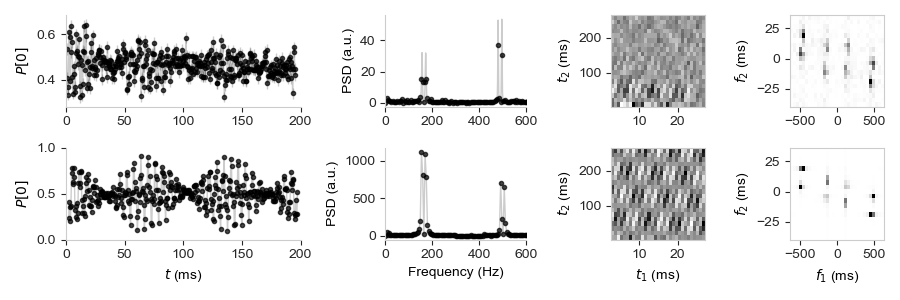

In [7]:
fig, ax = plt.subplots(2,4, figsize = [9,3], gridspec_kw={'width_ratios': [5, 3,2,2]})


xmax = 200
fmax = 600

ax[0,0].errorbar(data_dict_1D['x_1D'],data_dict_1D['y_1D'],data_dict_1D['y_e_1D'], color = exp_color, fmt = '-', alpha = fit_alpha)
ax[0,0].scatter(data_dict_1D['x_1D'],data_dict_1D['y_1D'], color = exp_color, marker ='.', alpha = exp_alpha)


#Sim
ax[1,0].plot(sim_dict_1D['x_vals'],(np.array(sim_dict_1D['y_vals'])+1)/2, color = fit_color, alpha =fit_alpha)
ax[1,0].scatter(sim_dict_1D['x_vals'],(np.array(sim_dict_1D['y_vals'])+1)/2, color = exp_color, marker ='.', alpha = exp_alpha)
ax[1,0].set_ylim(0,1)

for i in [0,1]:
    ax[i,0].set_xlim(0,xmax)
    ax[i,0].set_ylabel('$P[0]$')
    if i == 1:
        ax[i,0].set_xlabel('$t$ (ms)')

# PSD
ax[0,1].plot(data_dict_1D['freq1_fit'],data_dict_1D['PSD1_fit'], color = fit_color, alpha =fit_alpha)
ax[0,1].errorbar(data_dict_1D['freq1'],data_dict_1D['PSD1'],data_dict_1D['PSD1_error'], fmt = '.', color = exp_color, alpha = exp_alpha)

# Sim
ax[1,1].plot(sim_dict_1D['freq1'],sim_dict_1D['PSD1'], color = fit_color, alpha =fit_alpha)
ax[1,1].scatter(sim_dict_1D['freq1'],sim_dict_1D['PSD1'], marker = '.', color = exp_color, alpha = exp_alpha)

for i in [0,1]:
    ax[i,1].set_xlim(0,fmax)
    ax[i,1].set_ylabel('PSD (a.u.)')
    if i == 1:
        ax[i,1].set_xlabel('Frequency (Hz)')

for i in [0,1]:
    for j in [0,1]:
        ax[i,j].spines["top"].set_visible(False)
        ax[i,j].spines["right"].set_visible(False)
                    

# 2D ENES
# Time domain
ax[0,2].pcolormesh(data_dict['x1'] ,data_dict['x2'] ,np.transpose(data_dict['data_2D']),  
                 cmap = cmap_2D, 
                 shading = 'auto')
# sim
ax[1,2].pcolormesh(sim_dict_2D['x1'], sim_dict_2D['x2'] ,np.transpose(sim_dict_2D['data']),  
                 cmap = cmap_2D, 
                 shading = 'auto')

for i in [0,1]:
    ax[i,2].set_ylabel('$t_2$ (ms)')
    if i == 1:
        ax[i,2].set_xlabel('$t_1$ (ms)')



# PSD
ax[0,3].pcolormesh(data_dict['f1'] ,data_dict['f2'] ,np.transpose(data_dict['PSD2D']),  
                 cmap = cmap_2D, 
                 shading = 'auto', 
                 vmax = np.max(data_dict['PSD2D'])*rvmax) 
# sim
ax[1,3].pcolormesh(sim_dict_2D['f1'] ,sim_dict_2D['f2'] ,np.transpose(sim_dict_2D['PSD2D']),  
                 cmap = cmap_2D, 
                 shading = 'auto',
                 vmax = np.max(sim_dict_2D['PSD2D'])*rvmax)
for i in [0,1]:
#     ax[i,2].set_xlim(0,xmax)
    ax[i,3].set_ylabel('$f_2$ (ms)')
    if i == 1:
        ax[i,3].set_xlabel('$f_1$ (ms)')



plt.tight_layout()

### Save figure

In [8]:
plt.savefig('figure_s2.pdf', bbox_inches='tight')